In [1]:
import pandas as pd

In [2]:
f=pd.read_csv("Teen_Mental_Health_Dataset.csv")
df=pd.DataFrame(f)
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [5]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [9]:
df.duplicated().unique

<bound method Series.unique of 0       False
1       False
2       False
3       False
4       False
        ...  
1195    False
1196    False
1197    False
1198    False
1199    False
Length: 1200, dtype: bool>

In [10]:
df.dtypes

age                           int64
gender                       object
daily_social_media_hours    float64
platform_usage               object
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level     object
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,mean_absolute_error,classification_report,confusion_matrix,r2_score,mean_squared_error

In [18]:
x=df.drop("depression_label",axis=1)
y=df["depression_label"]
x=pd.get_dummies(x)

In [19]:
d={"model":[],"acc":[],"test":[]}  
test=[0.05,0.10,0.15,0.20,0.25]
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    d["model"].append("knn")
    d["test"].append(i)
    knn=KNeighborsClassifier(n_neighbors=29)
    knn.fit(x_train,y_train)
    d["acc"].append(accuracy_score(y_test,knn.predict(x_test)))
    d["model"].append("dt")
    d["test"].append(i)
    dt=DecisionTreeClassifier(criterion="entropy",random_state=42,max_depth=4)
    dt.fit(x_train,y_train)
    d["acc"].append(accuracy_score(y_test,dt.predict(x_test)))
    d["model"].append("rf")
    d["test"].append(i)
    rf=RandomForestClassifier(criterion="entropy",n_estimators=100,random_state=42,max_depth=4)
    rf.fit(x_train,y_train)
    d["acc"].append(accuracy_score(y_test,rf.predict(x_test)))
    d["model"].append("svm")
    d["test"].append(i)
    svm=SVC(C=10,kernel="rbf",random_state=42)
    svm.fit(x_train,y_train)
    d["acc"].append(accuracy_score(y_test,svm.predict(x_test)))
df=pd.DataFrame(d)
print(df) 

   model       acc  test
0    knn  0.933333  0.05
1     dt  1.000000  0.05
2     rf  0.933333  0.05
3    svm  0.950000  0.05
4    knn  0.958333  0.10
5     dt  1.000000  0.10
6     rf  0.958333  0.10
7    svm  0.975000  0.10
8    knn  0.972222  0.15
9     dt  1.000000  0.15
10    rf  0.972222  0.15
11   svm  0.983333  0.15
12   knn  0.975000  0.20
13    dt  1.000000  0.20
14    rf  0.975000  0.20
15   svm  0.983333  0.20
16   knn  0.973333  0.25
17    dt  0.996667  0.25
18    rf  0.973333  0.25
19   svm  0.983333  0.25


In [ ]:
from sklearn.linear_model import LinearRegression

In [31]:
# ===============================
# Import Required Libraries
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# (a) Load Dataset
# ===============================
data = pd.read_csv("Teen_Mental_Health_Dataset.csv")

print("First 5 Rows:")
print(data.head())


First 5 Rows:
   age  gender  daily_social_media_hours platform_usage  sleep_hours  \
0   14    male                       7.9      Instagram          7.4   
1   19  female                       1.9         TikTok          8.0   
2   17  female                       1.3      Instagram          7.6   
3   15    male                       7.4         TikTok          6.9   
4   15  female                       4.7           Both          4.9   

   screen_time_before_sleep  academic_performance  physical_activity  \
0                       2.9                  3.01                1.5   
1                       2.9                  3.22                0.8   
2                       0.5                  3.92                0.0   
3                       1.6                  3.48                0.8   
4                       3.0                  2.37                1.4   

  social_interaction_level  stress_level  anxiety_level  addiction_level  \
0                      low             2    

In [39]:

# ===============================
# (b) Handle Missing Values
# ===============================
print("\nMissing Values:")
print(data.isnull().sum())

# Remove missing values
data = data.dropna()

# ===============================
# (c) Define X and y + Split
# ===============================
X=data.drop("depression_label",axis=1)
y=data["depression_label"]
X=pd.get_dummies(x)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

# ===============================
# (d) Train Polynomial Models
# ===============================
degrees = [3, 4, 5, 6]

models = {}
predictions = {}
mse_list = []
r2_list = []
ans={}
# ===============================
# (e) Train, Predict, Evaluate
# ===============================
for d in degrees:

    # Polynomial Transformation
    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Train Model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Prediction
    y_pred = model.predict(X_test_poly)

    # Evaluation
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store Results
    models[d] = (model, poly)
    predictions[d] = y_pred

    mse_list.append(mse)
    r2_list.append(r2)
    ans[d]=r2
    # Print Results
    print(f"\nDegree {d}")
    print("MSE :", mse)
    print("R2 Score :", r2)



Missing Values:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Degree 3
MSE : 0.03257321601906573
R2 Score : -0.254961233611265

Degree 4
MSE : 0.10185115779030356
R2 Score : -2.9240600176058726

Degree 5
MSE : 0.075001901996295
R2 Score : -1.8896280734873927

Degree 6
MSE : 0.07540107960416166
R2 Score : -1.9050073477630773


In [40]:
ans

{3: -0.254961233611265,
 4: -2.9240600176058726,
 5: -1.8896280734873927,
 6: -1.9050073477630773}

In [41]:
models

{3: (LinearRegression(), PolynomialFeatures(degree=3)),
 4: (LinearRegression(), PolynomialFeatures(degree=4)),
 5: (LinearRegression(), PolynomialFeatures(degree=5)),
 6: (LinearRegression(), PolynomialFeatures(degree=6))}

In [42]:
predictions

{3: array([-3.04513425e-03, -7.82827660e-02, -1.46220252e-02, -1.74312524e-01,
         3.28247495e-01, -8.82003829e-02, -2.53313594e-01,  2.49056883e-01,
        -5.95250651e-02, -5.58941886e-02, -3.65472361e-02,  1.97702125e-02,
         2.66991332e-02,  1.39663167e-01,  2.65239187e-01,  1.15559764e-01,
         5.10417894e-02, -1.33583836e-01, -7.85165355e-02, -1.86506204e-01,
        -1.78629689e-01, -2.77028605e-02, -1.75497584e-01, -3.02966163e-02,
        -3.51082616e-01,  1.54007860e-01, -8.26266333e-02,  7.69607499e-02,
        -1.88453250e-01,  2.06834748e-02, -5.91904446e-02,  6.76829368e-03,
         1.34672113e-01,  2.18168445e-01,  1.17461629e-01,  1.38721175e-01,
         1.65961690e-01,  4.68674377e-02,  4.52940889e-01,  2.07127400e-01,
        -1.73080020e-01,  4.53577712e-02, -1.69745021e-01, -6.92956969e-02,
        -1.05510168e-01, -9.95395705e-02,  9.36982110e-02, -1.64712958e-01,
         3.22738364e-02, -8.36217925e-02,  5.61963268e-01, -1.06510445e-02,
        -

In [43]:
r2_list

[-0.254961233611265,
 -2.9240600176058726,
 -1.8896280734873927,
 -1.9050073477630773]

In [44]:
mse_list

[0.03257321601906573,
 0.10185115779030356,
 0.075001901996295,
 0.07540107960416166]

ValueError: x and y must be the same size

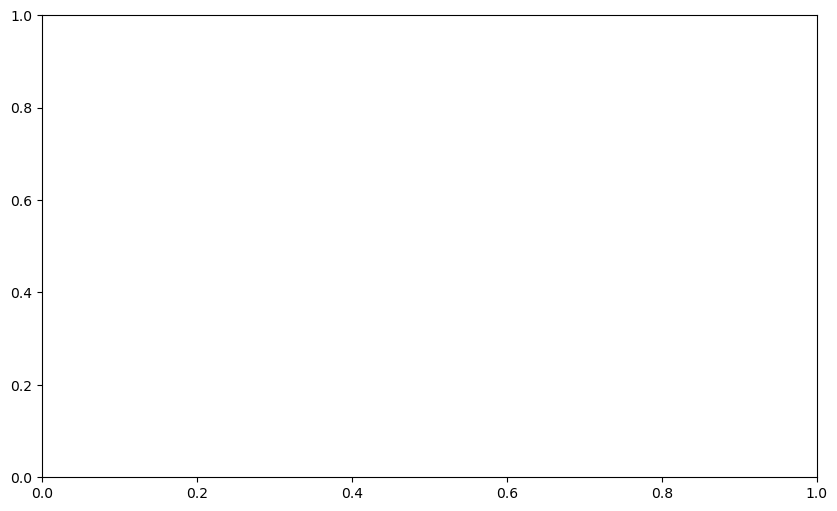

In [45]:
# ===============================
# (f) Plot Actual vs Predicted
# ===============================
plt.figure(figsize=(10, 6))

# Actual Values
plt.scatter(X_test, y_test, color='black', label='Actual')

# Predicted Values
for d in degrees:
    plt.scatter(X_test, predictions[d], label=f'Degree {d}')

plt.xlabel("Wind Speed")
plt.ylabel("Power")
plt.title("Actual vs Predicted Power (Polynomial Regression)")
plt.legend()
plt.show()


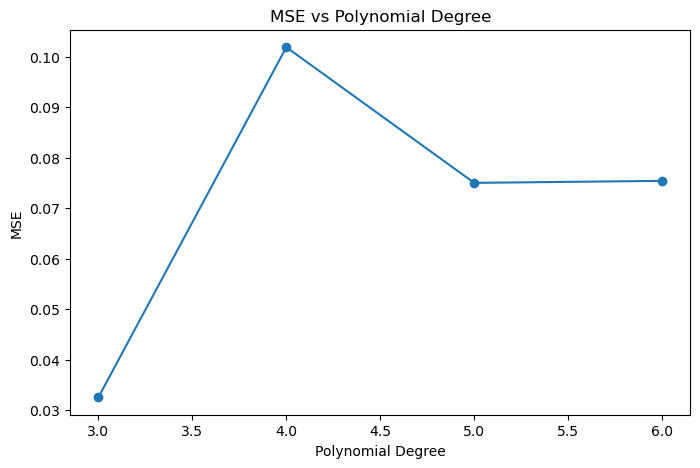


Best Degree (Lowest MSE): 3

Degree 3 Coefficients
Intercept : -49005518.42845946
Coefficients : [ 5.33060418e+07 -1.32720290e+08  3.09935944e+07 ...  0.00000000e+00
  0.00000000e+00  6.51186223e+05]

Degree 4 Coefficients
Intercept : 0.0859313740913592
Coefficients : [-2.90962822e-05  2.82464757e-05  2.88440332e-05 ...  0.00000000e+00
  0.00000000e+00  6.86796588e-06]

Degree 5 Coefficients
Intercept : 0.027887591084500122
Coefficients : [ 6.06067549e-08  4.47629790e-08 -1.36637440e-07 ...  0.00000000e+00
  0.00000000e+00  4.19505359e-08]

Degree 6 Coefficients
Intercept : 0.005775418029362548
Coefficients : [-2.37453022e-09  1.79596177e-10  1.61651871e-09 ...  0.00000000e+00
  0.00000000e+00  1.77957339e-10]


C:\Users\yasha\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


ValueError: X has 1 features, but PolynomialFeatures is expecting 17 features as input.

In [46]:

# ===============================
# (g) Plot MSE vs Degree
# ===============================
plt.figure(figsize=(8, 5))

plt.plot(degrees, mse_list, marker='o')

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("MSE vs Polynomial Degree")

plt.show()

# Best Degree
best_degree = degrees[np.argmin(mse_list)]

print("\nBest Degree (Lowest MSE):", best_degree)

# ===============================
# (h) Print Coefficients
# ===============================
for d in degrees:

    model, poly = models[d]

    print(f"\nDegree {d} Coefficients")
    print("Intercept :", model.intercept_)
    print("Coefficients :", model.coef_)

# ===============================
# (i) Predict for New Values
# ===============================
new_wind = np.array([[5], [10], [15], [20]])

for d in degrees:

    model, poly = models[d]

    new_poly = poly.transform(new_wind)

    pred = model.predict(new_poly)

    print(f"\nPredictions for Degree {d}")

    for ws, p in zip([5, 10, 15, 20], pred):
        print(f"Wind Speed {ws} --> Power = {p}")